This notebook trains three models for handwritten digit recognition on MNIST. The three final models are a Random Forest classifier, a fully connected neural network, and a simple convolutional neural network.

In [1]:
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

np.random.seed(42)
tf.random.set_seed(42)
BASE_DIR = Path.cwd()
MODELS_DIR = BASE_DIR / "saved_models"
MODELS_DIR.mkdir(exist_ok=True)

C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.2 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.2 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.2 at tensorflow/core/framework/

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train_mlp = X_train.reshape(len(X_train), -1)
X_test_mlp = X_test.reshape(len(X_test), -1)
X_train_cnn = X_train[..., np.newaxis]
X_test_cnn = X_test[..., np.newaxis]

X_train_mlp, X_validation_mlp, y_train, y_validation = train_test_split(
    X_train_mlp,
    y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train,
)
X_train_cnn = X_train_mlp.reshape(-1, 28, 28, 1)
X_validation_cnn = X_validation_mlp.reshape(-1, 28, 28, 1)

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 7s 1us/step 
(60000, 28, 28) (54000,) (10000, 28, 28) (10000,)


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

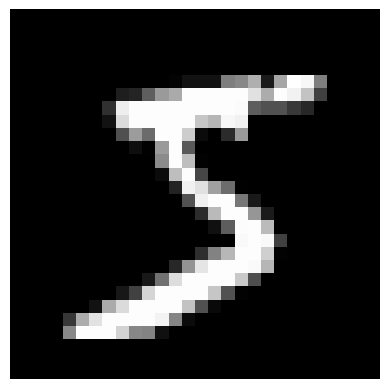

In [3]:
plt.imshow(X_train[0], cmap="gray")
plt.axis("off")

Every pixel is converted from an integer in the range 0 to 255 to a float in the range 0 to 1. The Random Forest and the fully connected network receive flattened 784-feature vectors. The CNN receives the original 28 by 28 image with one grayscale channel. Ten percent of the training set is kept as validation data for selecting hyperparameters, and the test set is used only for the final comparison.

In [4]:
mlp_options = [
    {"hidden_units": 64, "dropout": 0.0, "learning_rate": 0.001, "batch_size": 128},
    {"hidden_units": 128, "dropout": 0.2, "learning_rate": 0.001, "batch_size": 128},
    {"hidden_units": 256, "dropout": 0.2, "learning_rate": 0.0005, "batch_size": 64},
]

mlp_results = []
for option in mlp_options:
    candidate = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(784,)),
        tf.keras.layers.Dense(option["hidden_units"], activation="relu"),
        tf.keras.layers.Dropout(option["dropout"]),
        tf.keras.layers.Dense(10, activation="softmax"),
    ])
    candidate.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=option["learning_rate"]),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    start = time.perf_counter()
    history = candidate.fit(
        X_train_mlp,
        y_train,
        validation_data=(X_validation_mlp, y_validation),
        epochs=8,
        batch_size=option["batch_size"],
        verbose=0,
    )
    elapsed = time.perf_counter() - start
    best_validation = max(history.history["val_accuracy"])
    mlp_results.append({**option, "validation_accuracy": best_validation, "training_seconds": elapsed})

mlp_results = pd.DataFrame(mlp_results)
mlp_results

,hidden_units,dropout,learning_rate,batch_size,validation_accuracy,training_seconds
0,64,0.0,0.0010,128,0.968167,18.028537
1,128,0.2,0.0010,128,0.973167,26.087948
2,256,0.2,0.0005,64,0.976833,47.896320


In [5]:
best_mlp_option = mlp_results.sort_values("validation_accuracy", ascending=False).iloc[0].to_dict()
mlp = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    tf.keras.layers.Dense(int(best_mlp_option["hidden_units"]), activation="relu"),
    tf.keras.layers.Dropout(float(best_mlp_option["dropout"])),
    tf.keras.layers.Dense(10, activation="softmax"),
])
mlp.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=float(best_mlp_option["learning_rate"])),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
mlp_start = time.perf_counter()
mlp.fit(
    X_train_mlp,
    y_train,
    validation_data=(X_validation_mlp, y_validation),
    epochs=12,
    batch_size=int(best_mlp_option["batch_size"]),
    verbose=1,
)
mlp_seconds = time.perf_counter() - mlp_start
mlp_test_loss, mlp_test_accuracy = mlp.evaluate(X_test_mlp, y_test, verbose=0)
print(mlp_test_accuracy, mlp_seconds)

Epoch 1/12
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8934 - loss: 0.3802 - val_accuracy: 0.9415 - val_loss: 0.2082
Epoch 2/12
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9474 - loss: 0.1804 - val_accuracy: 0.9572 - val_loss: 0.1518
Epoch 3/12
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9613 - loss: 0.1328 - val_accuracy: 0.9662 - val_loss: 0.1228
Epoch 4/12
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9701 - loss: 0.1040 - val_accuracy: 0.9690 - val_loss: 0.1060
Epoch 5/12
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9749 - loss: 0.0858 - val_accuracy: 0.9722 - val_loss: 0.0951
Epoch 6/12
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9787 - loss: 0.0730 - val_accuracy: 0.9727 - val_loss: 0.0898
Epoch 7/12
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9818 - loss: 0.0624 - val_accuracy: 0.9760 - val_loss: 0.0860
Epoch 8/12
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9836 - loss: 0.0544 - val_accuracy: 0.

In [6]:
cnn_options = [
    {"filters": 16, "dense_units": 64, "learning_rate": 0.001, "batch_size": 128},
    {"filters": 32, "dense_units": 128, "learning_rate": 0.001, "batch_size": 128},
]

cnn_results = []
for option in cnn_options:
    candidate = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(28, 28, 1)),
        tf.keras.layers.Conv2D(option["filters"], 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(option["dense_units"], activation="relu"),
        tf.keras.layers.Dense(10, activation="softmax"),
    ])
    candidate.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=option["learning_rate"]),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    start = time.perf_counter()
    history = candidate.fit(
        X_train_cnn,
        y_train,
        validation_data=(X_validation_cnn, y_validation),
        epochs=6,
        batch_size=option["batch_size"],
        verbose=0,
    )
    elapsed = time.perf_counter() - start
    best_validation = max(history.history["val_accuracy"])
    cnn_results.append({**option, "validation_accuracy": best_validation, "training_seconds": elapsed})

cnn_results = pd.DataFrame(cnn_results)
cnn_results

,filters,dense_units,learning_rate,batch_size,validation_accuracy,training_seconds
0,16,64,0.001,128,0.984000,35.624648
1,32,128,0.001,128,0.984333,50.371865


In [7]:
best_cnn_option = cnn_results.sort_values("validation_accuracy", ascending=False).iloc[0].to_dict()
cnn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(int(best_cnn_option["filters"]), 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(int(best_cnn_option["dense_units"]), activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax"),
])
cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=float(best_cnn_option["learning_rate"])),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
cnn_start = time.perf_counter()
cnn.fit(
    X_train_cnn,
    y_train,
    validation_data=(X_validation_cnn, y_validation),
    epochs=10,
    batch_size=int(best_cnn_option["batch_size"]),
    verbose=1,
)
cnn_seconds = time.perf_counter() - cnn_start
cnn_test_loss, cnn_test_accuracy = cnn.evaluate(X_test_cnn, y_test, verbose=0)
print(cnn_test_accuracy, cnn_seconds)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9355 - loss: 0.2299 - val_accuracy: 0.9703 - val_loss: 0.1055
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9795 - loss: 0.0703 - val_accuracy: 0.9810 - val_loss: 0.0705
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9856 - loss: 0.0478 - val_accuracy: 0.9833 - val_loss: 0.0610
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9896 - loss: 0.0351 - val_accuracy: 0.9832 - val_loss: 0.0609
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9924 - loss: 0.0262 - val_accuracy: 0.9825 - val_loss: 0.0646
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9947 - loss: 0.0196 - val_accuracy: 0.9835 - val_loss: 0.0639
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9965 - loss: 0.0142 - val_accuracy: 0.9847 - val_loss: 0.0642
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9975 - loss: 0.0105 - val_acc

In [8]:
rf_options = [
    {"n_estimators": 80, "max_features": "sqrt", "min_samples_leaf": 1},
    {"n_estimators": 150, "max_features": "sqrt", "min_samples_leaf": 1},
    {"n_estimators": 150, "max_features": 0.5, "min_samples_leaf": 1},
]

rf_results = []
for option in rf_options:
    candidate = RandomForestClassifier(random_state=42, n_jobs=-1, **option)
    start = time.perf_counter()
    candidate.fit(X_train_mlp, y_train)
    elapsed = time.perf_counter() - start
    validation_accuracy = accuracy_score(y_validation, candidate.predict(X_validation_mlp))
    rf_results.append({**option, "validation_accuracy": validation_accuracy, "training_seconds": elapsed})

rf_results = pd.DataFrame(rf_results)
rf_results

,n_estimators,max_features,min_samples_leaf,validation_accuracy,training_seconds
0,80,sqrt,1,0.966000,11.620830
1,150,sqrt,1,0.967000,22.481145
2,150,0.5,1,0.964833,345.606668


In [9]:
best_rf_option = rf_results.sort_values("validation_accuracy", ascending=False).iloc[0].to_dict()
rf = RandomForestClassifier(
    n_estimators=int(best_rf_option["n_estimators"]),
    max_features=best_rf_option["max_features"],
    min_samples_leaf=int(best_rf_option["min_samples_leaf"]),
    random_state=42,
    n_jobs=-1,
)
rf_start = time.perf_counter()
rf.fit(X_train_mlp, y_train)
rf_seconds = time.perf_counter() - rf_start
rf_predictions = rf.predict(X_test_mlp)
rf_test_accuracy = accuracy_score(y_test, rf_predictions)
print(rf_test_accuracy, rf_seconds)

0.9698 23.598399900001823


In [10]:
comparison = pd.DataFrame([
    {"model": "Random Forest", "test_accuracy": rf_test_accuracy, "training_seconds": rf_seconds, "parameters": rf.n_estimators},
    {"model": "Neural Network", "test_accuracy": mlp_test_accuracy, "training_seconds": mlp_seconds, "parameters": mlp.count_params()},
    {"model": "CNN", "test_accuracy": cnn_test_accuracy, "training_seconds": cnn_seconds, "parameters": cnn.count_params()},
]).sort_values("test_accuracy", ascending=False)
comparison

,model,test_accuracy,training_seconds,parameters
2,CNN,0.9838,84.542384,693962
1,Neural Network,0.9800,80.248101,203530
0,Random Forest,0.9698,23.598400,150


In [11]:
print(classification_report(y_test, rf_predictions))
cnn_predictions = np.argmax(cnn.predict(X_test_cnn, verbose=0), axis=1)
print(confusion_matrix(y_test, cnn_predictions))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.97      0.97      1032
           3       0.96      0.97      0.96      1010
           4       0.97      0.97      0.97       982
           5       0.97      0.96      0.97       892
           6       0.97      0.98      0.98       958
           7       0.97      0.96      0.97      1028
           8       0.96      0.96      0.96       974
           9       0.95      0.96      0.95      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000

[[ 976    0    0    0    0    0    1    1    2    0]
 [   0 1125    3    0    0    1    2    1    3    0]
 [   2    0 1013    3    0    0    1    7    5    1]
 [   0    0    1  989    0   11    0    5    4    0]
 [   0    0    5    0  960   

The CNN is expected to be the best model for this task because convolution and pooling preserve the spatial structure of the digit and make the model less sensitive to small shifts in the drawing. The Random Forest is a useful classical baseline and does not require neural-network training, while the fully connected network is simpler than the CNN but does not model local image patterns directly. The final choice should be based on the measured test accuracy and training time in the comparison table, not on accuracy alone.

In [12]:
mlp.save(MODELS_DIR / "mnist_mlp.keras")
cnn.save(MODELS_DIR / "mnist_cnn.keras")
joblib.dump(rf, MODELS_DIR / "mnist_random_forest.joblib")
print(list(MODELS_DIR.iterdir()))

[WindowsPath('C:/Users/user/Downloads/Material/Material/DeepLearningML/1_keras_fashion_mnist_neural_net/Exercise/saved_models/mnist_cnn.keras'), WindowsPath('C:/Users/user/Downloads/Material/Material/DeepLearningML/1_keras_fashion_mnist_neural_net/Exercise/saved_models/mnist_mlp.keras'), WindowsPath('C:/Users/user/Downloads/Material/Material/DeepLearningML/1_keras_fashion_mnist_neural_net/Exercise/saved_models/mnist_random_forest.joblib')]


Run the interactive application from this folder after executing the notebook and creating the three files in saved_models:

python app.py

The application opens a canvas for drawing with the mouse. Select one of the saved models, press Predict to classify the drawing, and press Clear to draw another digit. The required packages are tensorflow, scikit-learn, joblib, pillow, matplotlib, numpy, and pandas.